# 모델 비교: 단계별 변수 제거 효과

| 모델 | 데이터 | 변수 수 |
|------|--------|--------|
| Baseline | 시청 이력 없는 구독 정보만 | ~12개 |
| 전처리 완료 | Membership_features.csv (전체 파생변수) | 100개 |
| 다중공선성 제거 | Membership_features_clean.csv (VIF 기반 제거) | ~81개 |
| SHAP 제거 | VIF 제거 후 SHAP 하위 변수 추가 제거 | ~70개 |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import xgboost as xgb

BASE = Path('..').resolve()
SEED = 42

# 데이터 로드
df_all   = pd.read_csv(BASE / '_data/02_interim/260510_features/Membership_features.csv',   encoding='utf-8-sig')
df_clean = pd.read_csv(BASE / '_data/02_interim/260510_features/Membership_features_clean.csv', encoding='utf-8-sig')

print(f'전처리 완료 shape:    {df_all.shape}')
print(f'다중공선성 제거 shape: {df_clean.shape}')

전처리 완료 shape:    (23343, 100)
다중공선성 제거 shape: (23343, 81)


## Feature Set 정의

In [2]:
# 공통 제외 컬럼
EXCLUDE_ALWAYS = ['USER_KEY','product_code','payment_device','device_group',
                   'gender','age_group','is_repurchase']

# ── 1. Baseline: 시청 이력 없이 구독 정보만 ──────────────────────────────
BASELINE_COLS = [
    'price', 'billing_method', 'is_churn_prevented', 'is_user_verified',
    'age', 'gender_enc', 'duration_days', 'is_standard', 'is_premium',
    'price_per_day', 'is_usd', 'reg_hour_group',
]
BASELINE_COLS = [c for c in BASELINE_COLS if c in df_all.columns]

# ── 2. 전처리 완료: 모든 파생변수 (Membership_features.csv) ──────────────
ALL_COLS = [c for c in df_all.columns if c not in EXCLUDE_ALWAYS]

# ── 3. 다중공선성 제거: VIF 기반 제거 (Membership_features_clean.csv) ───
VIF_COLS = [c for c in df_clean.columns if c not in EXCLUDE_ALWAYS]

# ── 4. SHAP 제거: VIF 이후 중요도 하위 변수 추가 제거 ────────────────────
SHAP_LOW_DROP = [
    'retention_w2', 'retention_w3',  # binary → ratio 버전이 Top6에 이미 존재
    'reg_hour_group',                 # 예측력 낮음
    'is_usd',                         # price_per_day가 이미 가격 커버
    'vh_one_min_watch_ratio',         # vh_short_watch_ratio(5분)와 중복
    'avg_rewatch_ratio',              # 예측력 미미
    'front_loaded_flag', 'late_binge_flag',  # week1_ratio, dur_w3가 커버
    'weekend_watch_ratio',            # 예측력 미미
    'is_new_movie_ratio',             # 예측력 미미
    'age_x_screen', 'verified_x_age', 'is_senior_unverified',  # 인구통계 상호작용
]
SHAP_COLS = [c for c in VIF_COLS if c not in SHAP_LOW_DROP]

print(f'[1] Baseline:        {len(BASELINE_COLS):3d}개')
print(f'[2] 전처리 완료:     {len(ALL_COLS):3d}개')
print(f'[3] 다중공선성 제거: {len(VIF_COLS):3d}개')
print(f'[4] SHAP 제거:       {len(SHAP_COLS):3d}개')

[1] Baseline:         12개
[2] 전처리 완료:      93개
[3] 다중공선성 제거:  74개
[4] SHAP 제거:        61개


## 학습/평가 함수

In [3]:
def encode_and_split(df, feature_cols):
    df_ = df.copy()
    for col in df_.select_dtypes(include='object').columns:
        if col in feature_cols:
            df_[col] = LabelEncoder().fit_transform(df_[col].astype(str))
    X = df_[feature_cols].fillna(0)
    y = df_['is_repurchase']
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

def train_evaluate(df, feature_cols, label):
    X_train, X_test, y_train, y_test = encode_and_split(df, feature_cols)
    spw = (y_train == 0).sum() / (y_train == 1).sum()

    model = xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', early_stopping_rounds=50,
        random_state=SEED, n_jobs=-1, verbosity=0
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    result = {
        '모델':        label,
        '변수 수':     len(feature_cols),
        'AUC-ROC':    round(roc_auc_score(y_test, y_proba), 4),
        'F1':         round(f1_score(y_test, y_pred), 4),
        'Precision':  round(precision_score(y_test, y_pred), 4),
        'Recall':     round(recall_score(y_test, y_pred), 4),
        'Best iter.': model.best_iteration,
    }
    print(f"[{label}] AUC={result['AUC-ROC']:.4f}  F1={result['F1']:.4f}  변수={len(feature_cols)}개  iter={model.best_iteration}")
    return result

## 4개 모델 학습

In [4]:
results = []
results.append(train_evaluate(df_all,   BASELINE_COLS, 'Baseline'))
results.append(train_evaluate(df_all,   ALL_COLS,      '전처리 완료'))
results.append(train_evaluate(df_clean, VIF_COLS,      '다중공선성 제거'))
results.append(train_evaluate(df_clean, SHAP_COLS,     'SHAP 제거'))

result_df = pd.DataFrame(results)
print()
print('=== 비교 결과 ===')
print(result_df.to_string(index=False))

[Baseline] AUC=0.5690  F1=0.6491  변수=12개  iter=55
[전처리 완료] AUC=0.8845  F1=0.8557  변수=93개  iter=496
[다중공선성 제거] AUC=0.8826  F1=0.8582  변수=74개  iter=483
[SHAP 제거] AUC=0.8837  F1=0.8538  변수=61개  iter=499

=== 비교 결과 ===
      모델  변수 수  AUC-ROC     F1  Precision  Recall  Best iter.
Baseline    12   0.5690 0.6491     0.7571  0.5681          55
  전처리 완료    93   0.8845 0.8557     0.8978  0.8174         496
다중공선성 제거    74   0.8826 0.8582     0.9015  0.8189         483
 SHAP 제거    61   0.8837 0.8538     0.9012  0.8111         499


## 시각화

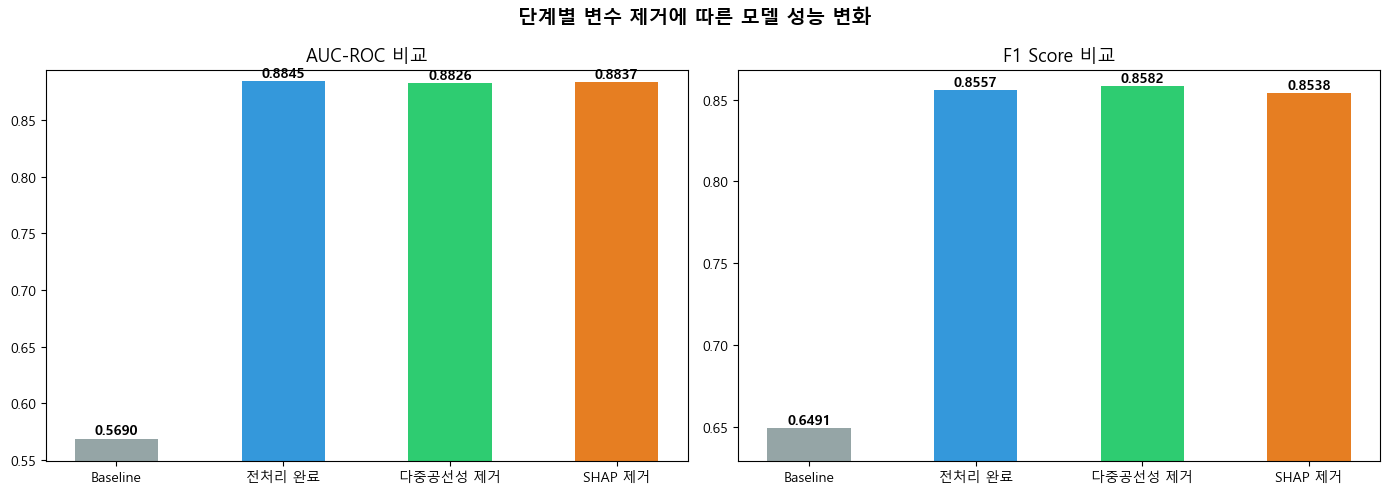

In [5]:
labels = result_df['모델'].tolist()
x = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC-ROC
ax = axes[0]
bars = ax.bar(x, result_df['AUC-ROC'], width=0.5, color=['#95a5a6','#3498db','#2ecc71','#e67e22'])
ax.set_title('AUC-ROC 비교', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
auc_min = result_df['AUC-ROC'].min()
ax.set_ylim(max(0, auc_min - 0.02), result_df['AUC-ROC'].max() + 0.01)
for bar, val in zip(bars, result_df['AUC-ROC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# F1
ax = axes[1]
bars = ax.bar(x, result_df['F1'], width=0.5, color=['#95a5a6','#3498db','#2ecc71','#e67e22'])
ax.set_title('F1 Score 비교', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
f1_min = result_df['F1'].min()
ax.set_ylim(max(0, f1_min - 0.02), result_df['F1'].max() + 0.01)
for bar, val in zip(bars, result_df['F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('단계별 변수 제거에 따른 모델 성능 변화', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

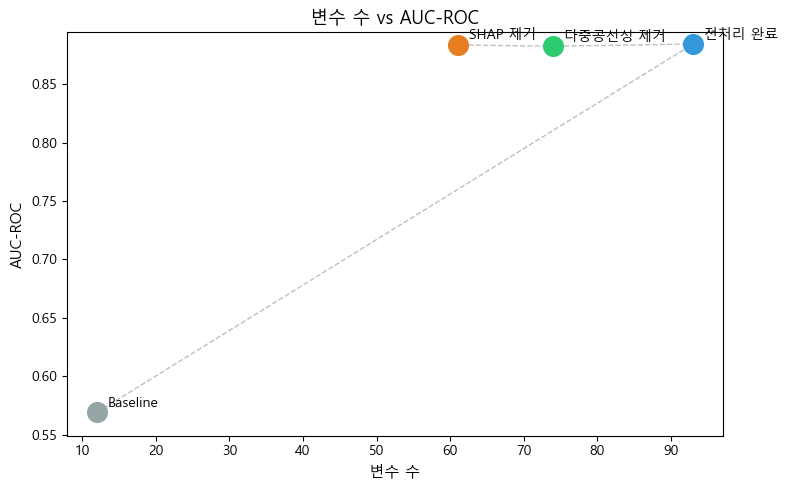


=== 최종 해석 ===
최고 AUC 모델: 전처리 완료 (0.8845)
최고 F1  모델: 다중공선성 제거 (0.8582)
Baseline 대비 [전처리 완료]: AUC +0.3155
Baseline 대비 [다중공선성 제거]: AUC +0.3136
Baseline 대비 [SHAP 제거]: AUC +0.3147


In [6]:
# 변수 수 vs AUC 산점도
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#95a5a6','#3498db','#2ecc71','#e67e22']
for i, row in result_df.iterrows():
    ax.scatter(row['변수 수'], row['AUC-ROC'], s=200, color=colors[i], zorder=5)
    ax.annotate(row['모델'], (row['변수 수'], row['AUC-ROC']),
                textcoords='offset points', xytext=(8, 4), fontsize=10)

ax.plot(result_df['변수 수'], result_df['AUC-ROC'],
        '--', color='gray', linewidth=1, alpha=0.5)
ax.set_xlabel('변수 수', fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title('변수 수 vs AUC-ROC', fontsize=13)
auc_min = result_df['AUC-ROC'].min()
ax.set_ylim(max(0, auc_min - 0.02), result_df['AUC-ROC'].max() + 0.01)
plt.tight_layout()
plt.show()

# 최종 요약
print('\n=== 최종 해석 ===')
best = result_df.loc[result_df['AUC-ROC'].idxmax()]
print(f"최고 AUC 모델: {best['모델']} ({best['AUC-ROC']:.4f})")
best_f1 = result_df.loc[result_df['F1'].idxmax()]
print(f"최고 F1  모델: {best_f1['모델']} ({best_f1['F1']:.4f})")

baseline_auc = result_df.loc[result_df['모델'] == 'Baseline', 'AUC-ROC'].values[0]
for _, row in result_df[result_df['모델'] != 'Baseline'].iterrows():
    diff = row['AUC-ROC'] - baseline_auc
    print(f"Baseline 대비 [{row['모델']}]: AUC {diff:+.4f}")